In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


PATHS = {
    "High":   "BD_10_H_EvalData.csv",
    "Medium": "BD_10_M_EvalData.csv",
    "Low":    "BD_10_Low_EvalData.csv",
}

TASKS = [
    ("XY-move",             "XY stage\nmotion"),
    ("CapturingTime",       "Image\nacquisition"),
    ("Total_Focus_Process", "Image\nconstruction"),
    ("Encoding_Time",       "Image\ncompression"),
]

COLORS = {
    "High":   "#e97132",
    "Medium": "#0f9ed5",
    "Low":    "#4ea72e",
}


def load_eval_csv(path):
    """
    BD_10_*_EvalData.csv を読み込み、
    XY-move / CapturingTime / Total_Focus_Process / Encoding_Time の
    4列を秒単位 (ms → s) で返す。
    末尾の 'Imaging Time' 行や 'Slide Time in total' 行は除外する。
    """
    df = pd.read_csv(path, skiprows=11, header=0)

    mask = pd.to_numeric(df["Spot number"], errors="coerce").notna()
    df = df[mask].copy()

    cols = [c for c, _ in TASKS]
    df_sec = df[cols] / 1000.0

    return df_sec  # shape: (n_spots, 4)


In [2]:
testdata = load_eval_csv(PATHS["High"])
testdata.head()

,XY-move,CapturingTime,Total_Focus_Process,Encoding_Time
0,0.893,1.333,0.392,0.487
1,0.281,0.357,0.410,0.317
2,0.322,0.376,0.395,0.313
3,0.320,0.365,0.398,0.433
4,0.320,0.379,0.403,0.322


High: n = 163 imaging sections
Medium: n = 163 imaging sections
Low: n = 163 imaging sections


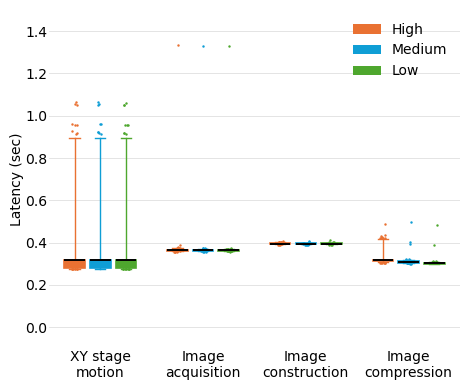

In [3]:

def plot_latency_boxplot(output_path):
    data = {qual: load_eval_csv(path) for qual, path in PATHS.items()}

    for qual, df in data.items():
        print(f"{qual}: n = {df.shape[0]} imaging sections")

    fig, ax = plt.subplots(figsize=(4.8, 4))

    x = np.arange(len(TASKS))  
    offset = 0.25              
    width = 0.20
    order = ["High", "Medium", "Low"]

    rng = np.random.default_rng(0)  # for jitter
    
    for i, qual in enumerate(order):
        pos = x + (i - 1) * offset
        vals = [data[qual][col].values for col, _ in TASKS]

        bp = ax.boxplot(
            vals,
            positions=pos,
            widths=width,
            patch_artist=True,
            showfliers=True, 
            whis=[5, 95],    
        )

        for box in bp["boxes"]:
            box.set_facecolor(COLORS[qual])
            box.set_alpha(1.0)
            box.set_edgecolor(COLORS[qual])
            box.set_linewidth(1.2)

        for whisker in bp["whiskers"]:
            whisker.set_color(COLORS[qual])
            whisker.set_linewidth(1.0)

        for cap in bp["caps"]:
            cap.set_color(COLORS[qual])
            cap.set_linewidth(1.0)

        for median in bp["medians"]:
            median.set_color('black')
            median.set_linewidth(1.4)

        jitter_width = width * 0.15
        for flier in bp["fliers"]:
            flier.set_marker(".")
            flier.set_markersize(3.5)
            flier.set_markerfacecolor(COLORS[qual])
            flier.set_markeredgecolor('none')

            xdata = flier.get_xdata()
            ydata = flier.get_ydata()
            x_jitter = xdata + rng.uniform(-jitter_width, jitter_width, size=len(xdata))
            flier.set_xdata(x_jitter)
            flier.set_ydata(ydata)

    ax.set_xlim(-0.5, len(TASKS) - 0.5)
    ax.set_ylim(-0.1, 1.5) 
    ax.set_xticks(x)
    ax.set_yticks(np.arange(0, 1.5, 0.2))
    ax.set_xticklabels([label for _, label in TASKS], ha="center")
    ax.tick_params(axis='both', which='major', labelsize=10, pad=1)
    ax.set_ylabel("Latency (sec)", fontsize=10, labelpad=1)

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='-', linewidth=0.5, color='0.85')
    ax.xaxis.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis='both', which='both', length=0)

    handles = [Patch(facecolor=COLORS[q], alpha=1, label=q) for q in order]
    ax.legend(handles=handles, title=None, frameon=False, loc="upper right")

    fig.tight_layout()
    fig.savefig(output_path, dpi=300)
    plt.show()


plot_latency_boxplot(output_path="scanner_latency.svg")
